# Student Performance Analysis and Prediction

### Imported Libraries

In [1]:
# I've imported all Libraries for Data Handling and Visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# I've imported all sklearn tools here
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Task 1 - Data Exploration with Pandas

In [2]:
df = pd.read_csv("students.csv")


##### Question 1: Print first 5 rows

In [3]:
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


##### Que 2. Print the shape (rows × columns) and the data type of each column using .dtypes. 
 

In [4]:
print("Shape of Dataset: ", df.shape)
print("\n")

# the shape of data is found out df.dtypes
print("Data Types of each Columns: ")
print(df.dtypes)

Shape of Dataset:  (15, 9)


Data Types of each Columns: 
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


##### Question 3 - Print summary statistics

In [5]:
# using the df.describe() statement, i'm displaying all summary statistic about the data
print(df.describe())

            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               2.800000   1.000000  

##### Question 4 - Count passed and failed students

In [6]:
# i'm checking here how many student have passed and how many failed
# for this i've used the "passed" column and used the 
# value_counts functions
# 1 --> pass
# 0 --> fail
pass_fail_count = df["passed"].value_counts()
print(pass_fail_count)

passed
1    9
0    6
Name: count, dtype: int64


##### Question 5 - Average score per subject for passing and failing students

In [7]:
# creating an array for each subject that will act like columsn
subject_cols = ["math", "science", "english", "history", "pe"]

# filtering the df with students who have passed(1) and failed(0)
passing_students_avg = df[df["passed"] == 1][subject_cols].mean()
failing_students_avg = df[df["passed"] == 0][subject_cols].mean()

# simply printing the outputs
print("Average subject scores for passing students:")
print(passing_students_avg)
print()

print("Average subject scores for failing students:")
print(failing_students_avg)

Average subject scores for passing students:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average subject scores for failing students:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


##### Question 6 - Student with highest overall average

In [8]:
subject_cols = ["math", "science", "english", "history", "pe"]

# creating a new column called overall average
df["overall_average"] = df[subject_cols].mean(axis=1)

# finding the highest value in overall_average column 
top_student = df.loc[df["overall_average"].idxmax()]

# printing the top student name and his average score
print("Student with the highest overall average:")
print(top_student[["name", "overall_average"]])

Student with the highest overall average:
name               Diana
overall_average     94.0
Name: 3, dtype: object


### Task 2 - Data Visualization with Matplotlib

In [9]:
# adding new column average score as mentioned in the assignment
subject_cols = ["math", "science", "english", "history", "pe"]
df["avg_score"] = df[subject_cols].mean(axis=1)

##### Question 1 - Bar chart of average score per subject

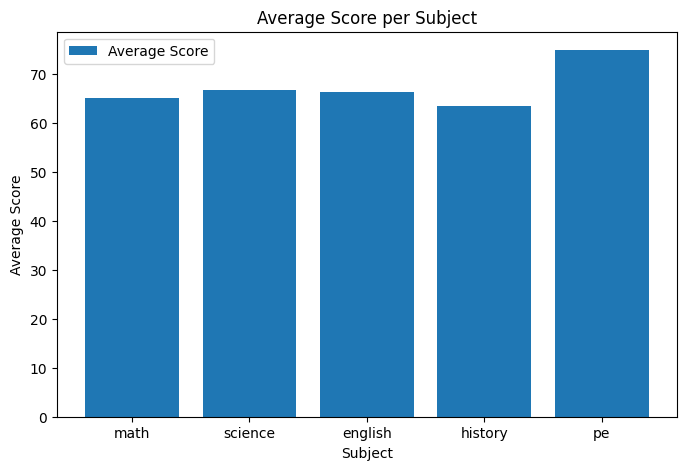

In [10]:
# calculating average score using the mean function
average_scores = df[subject_cols].mean()

# creating bar chart for average subject score
plt.figure(figsize=(8, 5))
plt.bar(average_scores.index, average_scores.values, label="Average Score")

# adding titles, axis labels and legend
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.legend()


plt.savefig("plot1_bar.png")
plt.show()

##### Question 2 - Histogram of math scores

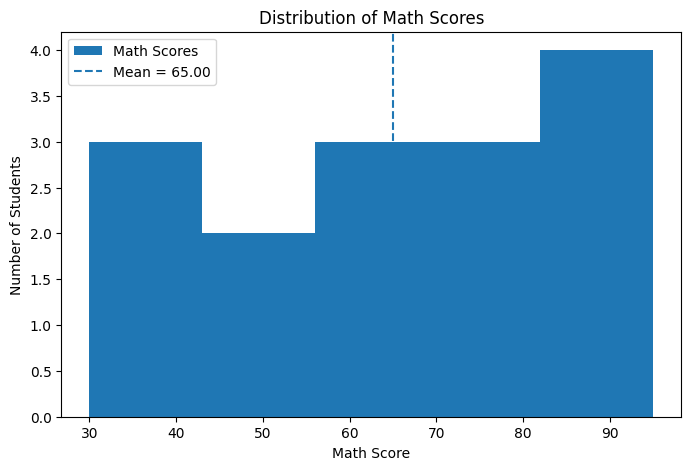

In [11]:
# calculating the avergae score in maths
math_mean = df["math"].mean()

# creating the plot Area
plt.figure(figsize=(8, 5))

# creating a histogram using maths score
plt.hist(df["math"], bins=5, label="Math Scores")

# draws a vertical line at the avergae math score
plt.axvline(math_mean, linestyle="--", label=f"Mean = {math_mean:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()

# saving the diagram and displaying
plt.savefig("plot2_histogram.png")
plt.show()

##### Question 3 - Scatter plot of study hours vs average score

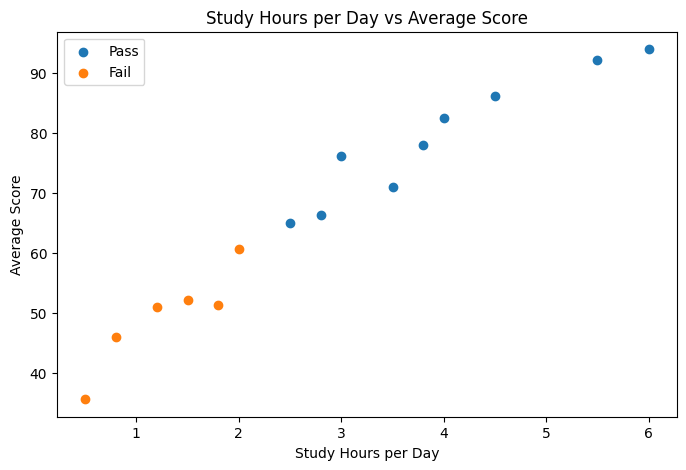

In [12]:
# creating pass and fail students
pass_students = df[df["passed"] == 1]
fail_students = df[df["passed"] == 0]

# creating the plot area
plt.figure(figsize=(8, 5))

# scatter plot 
plt.scatter(pass_students["study_hours_per_day"], pass_students["avg_score"], label="Pass")
plt.scatter(fail_students["study_hours_per_day"], fail_students["avg_score"], label="Fail")

plt.title("Study Hours per Day vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

# saving the plot and displaying it
plt.savefig("plot3_scatter.png")
plt.show()

##### Question 4 - Box plot of attendance for pass and fail students

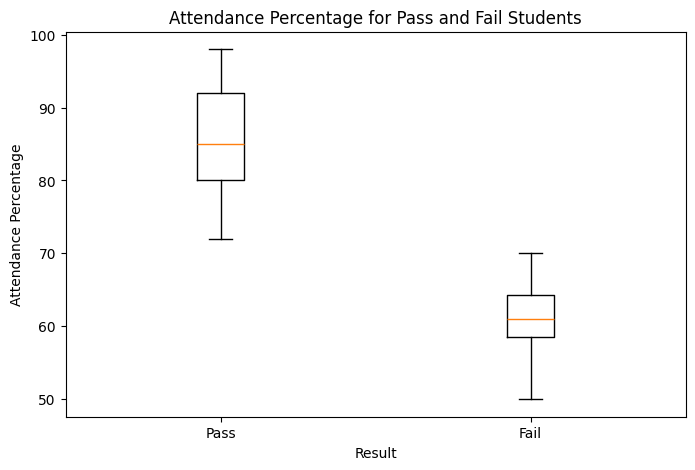

In [13]:
# creating pass and fail students
pass_attendance = df[df["passed"] == 1]["attendance_pct"].tolist()
fail_attendance = df[df["passed"] == 0]["attendance_pct"].tolist()

# creating plot area and starting with boxplot
plt.figure(figsize=(8, 5))
plt.boxplot([pass_attendance, fail_attendance], tick_labels=["Pass", "Fail"])

# marking the labes
plt.title("Attendance Percentage for Pass and Fail Students")
plt.xlabel("Result")
plt.ylabel("Attendance Percentage")

# 
plt.savefig("plot4_boxplot.png")
plt.show()

##### Question 5 - Line plot of math and science scores for every student

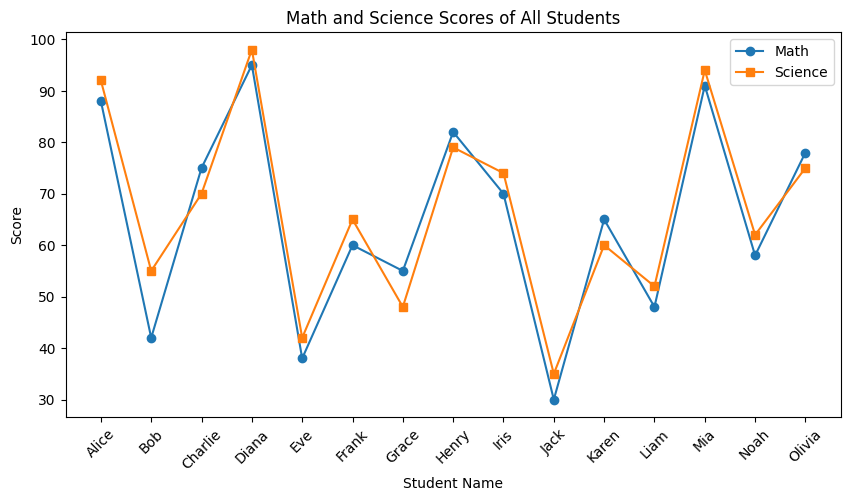

In [14]:
# creating the plot area
plt.figure(figsize=(10, 5))

# creating plots for maths and sceince
plt.plot(df["name"], df["math"], marker="o", label="Math")
plt.plot(df["name"], df["science"], marker="s", label="Science")

# naming the labels
plt.title("Math and Science Scores of All Students")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()

# saving the diagram and displaying the plot
plt.savefig("plot5_line.png")
plt.show()

### Task 3 - Data Visualization with Seaborn

##### Question 1 - Seaborn bar plots for math and science scores by pass or fail

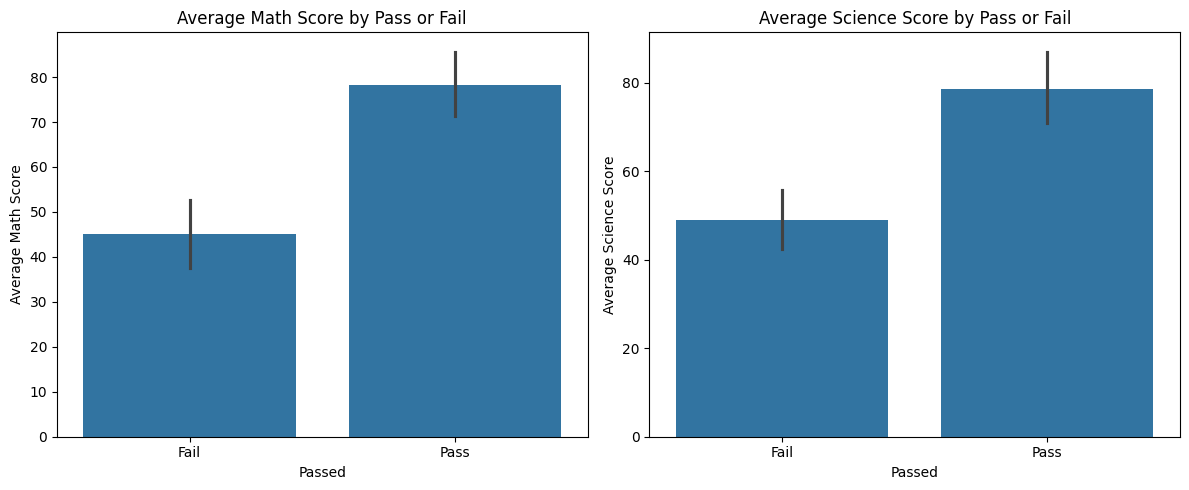

In [15]:
# creatignn the plot area
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# seaborn barplot for pass in maths
sns.barplot(data=df, x="passed", y="math", ax=axes[0])
axes[0].set_title("Average Math Score by Pass or Fail")
axes[0].set_xlabel("Passed")
axes[0].set_ylabel("Average Math Score")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Fail", "Pass"])

# seaborn barplot for pass in science
sns.barplot(data=df, x="passed", y="science", ax=axes[1])
axes[1].set_title("Average Science Score by Pass or Fail")
axes[1].set_xlabel("Passed")
axes[1].set_ylabel("Average Science Score")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Fail", "Pass"])

# saving the plot and displaying the plot
plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

##### Question 2 - Seaborn scatter plot of attendance and average score with regression lines

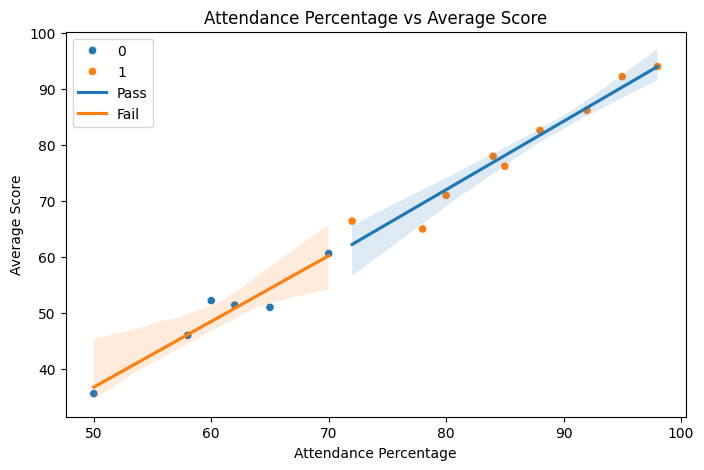

In [16]:
# creating the plot 
plt.figure(figsize=(8, 5))

# seaborn scatter plot
sns.scatterplot(data=df, x="attendance_pct", y="avg_score", hue="passed")

# adding a regression line for students who passed
sns.regplot(
    data=df[df["passed"] == 1],
    x="attendance_pct",
    y="avg_score",
    scatter=False,
    label="Pass"
)

# adding a regression line for students who failes
sns.regplot(
    data=df[df["passed"] == 0],
    x="attendance_pct",
    y="avg_score",
    scatter=False,
    label="Fail"
)

# labelling the plots
plt.title("Attendance Percentage vs Average Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()

# saving the plot and displaying it
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

##### Comment on Seaborn and Matplotlib

In [17]:
# I found Seaborn easier for grouped and styled plots because it creates cleaner graphs with less code.
# Matplotlib gave me more control over each part of the graph, but it needed more manual work for labels, styling, and layout.
# For simple custom plots I found Matplotlib useful, while Seaborn felt quicker for statistical visualizations.

### Task 4 - Machine Learning with scikit-learn

### step 1 -> Preparing Data:  

##### Question 1 - Prepare features and target

In [18]:
# storing the input columns
feature_cols = ["math", "science", "english", "history", "pe", "attendance_pct", "study_hours_per_day"]

# x --> marks, attendance and study hours
# y --> pass or fail
X = df[feature_cols]
y = df["passed"]

##### Question 2 - Split the data into train and test sets

In [19]:
# spliting data into 2 parts:
# a) training data  
# b) testing data  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##### Question 3 - Scale the feature values

In [20]:
# using standard scaler to adjust values so they are on similar scale
scaler = StandardScaler()

# learning scalling values and applies the scaling
X_train_scaled = scaler.fit_transform(X_train)

# applying data to test data
X_test_scaled = scaler.transform(X_test)

### Step 2 --> Train a Model

##### Question 1 - Train the logistic regression model

In [21]:
# Creating a logistic regression model
model = LogisticRegression()

# training the model usign the scaled data
model.fit(X_train_scaled, y_train)

# checking the training accuracy 
train_accuracy = model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_accuracy)

# a test accuracy of 1 means 100% correct
# whereas a test accuracy of 0.8 means 80% correct

Training Accuracy: 1.0


### Step 3 --> Evaluate the Model

##### Question 1 - Evaluating  the model accuracy

In [22]:
# asking the model to make prediction on test data
# y_pred contains values 0 -> fail and 1 -> pass
y_pred = model.predict(X_test_scaled)

# testing the accuracy on y_test(actual answers) and y_pred (predicted answers)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)
print()


# getting names of student in the test set
test_student_names = df.loc[X_test.index, "name"]

# looping through student name, acutal label and predicted labe
# if model predicted correct then we assign result to correct
# else we assign result to wrong
# and then we print the details
for name, actual, predicted in zip(test_student_names, y_test, y_pred):
    if actual == predicted:
        result = "Correct"
    else:
        result = "Wrong"
    
    print("Student Name:", name)
    print("Actual Label:", actual)
    print("Predicted Label:", predicted)
    print("Result:", result)
    print()

Test Accuracy: 1.0

Student Name: Jack
Actual Label: 0
Predicted Label: 0
Result: Correct

Student Name: Liam
Actual Label: 0
Predicted Label: 0
Result: Correct

Student Name: Alice
Actual Label: 1
Predicted Label: 1
Result: Correct



### Step 4 --> Feature Importance

##### Question 1 - Extract and sort feature coefficients

In [24]:
# coefficients learned from the logistic regression model are stored in 
# variable "coefficents"
# positive coefficient -> prediction pass
# negative coefficient -> prediction fail
coefficients = model.coef_[0]

# making a dataframe with feature name and coefficient value
# which will make it easire for me to read data
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": coefficients
})


# getting the absolute and sorting them so that we know weakest and strongest
feature_importance["Absolute Value"] = feature_importance["Coefficient"].abs()
feature_importance = feature_importance.sort_values(by="Absolute Value", ascending=False)

# printing the features of important values
print(feature_importance[["Feature", "Coefficient"]])

               Feature  Coefficient
2              english     0.812513
5       attendance_pct     0.521876
6  study_hours_per_day     0.484433
4                   pe     0.474974
0                 math     0.437944
1              science     0.323010
3              history     0.262929


##### Question 2 - Horizontal bar chart of feature coefficients

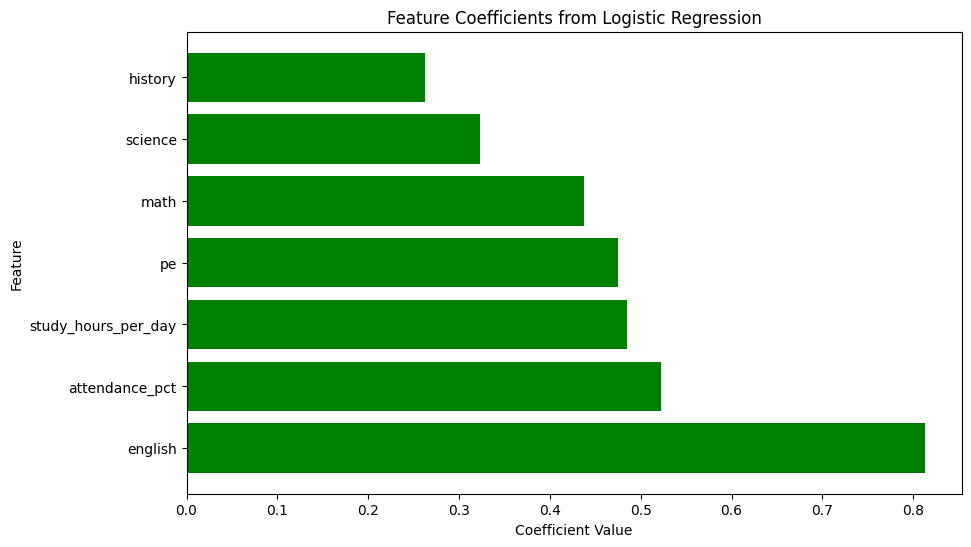

In [26]:
# we store bar colors in the variable color
colors = []

# we check coefficent in the feature_importance colums
# if coeffient >= 0 then we add green to color
# esle we add red to color
for value in feature_importance["Coefficient"]:
    if value >= 0:
        colors.append("green")
    else:
        colors.append("red")

# creating the plot ares
plt.figure(figsize=(10, 6))

# creating the barplot
plt.barh(feature_importance["Feature"], feature_importance["Coefficient"], color=colors)

# labeling the plot
plt.title("Feature Coefficients from Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

# saving the plot and displaying the plot
plt.savefig("plot8_feature_importance.png")
plt.show()

# understanding the graph
# if a bar goes to the right with a positive value, 
# that feature pushes the prediction toward pass
# if a bar goes to the left with a negative value, 
# that feature pushes the prediction toward fail

### Step 5 --> Prediction for a New Student

##### Question  - Predict pass or fail for a new student

In [28]:
# data of the new student(math,science,english,history,pe,attendance_pct,study_hours_per_day)
new_student = pd.DataFrame(
    [[75, 70, 68, 65, 80, 82, 3.2]],
    columns=feature_cols
)

# scaling the data of new_student using the same scaler so that model
# can use this to predict
new_student_scaled = scaler.transform(new_student)

# predicting if new_student will pass or fail
# pass -> 1
# fail -> 0
new_prediction = model.predict(new_student_scaled)
new_prediction_proba = model.predict_proba(new_student_scaled)

# printing if student passes or fails
if new_prediction[0] == 1:
    print("Prediction: Pass")
else:
    print("Prediction: Fail")

# printing the probability
print("Probability of Fail:", round(new_prediction_proba[0][0], 4))
print("Probability of Pass:", round(new_prediction_proba[0][1], 4))

Prediction: Pass
Probability of Fail: 0.092
Probability of Pass: 0.908
